E-commerce dataset cleaning and visualizing 

In [4]:
import pandas as pd

In [5]:
df = pd.read_excel("Data.xlsx")
df.head()


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [7]:
df.shape

(1200, 14)

In [8]:
df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [9]:
df["CouponCode"] = df["CouponCode"].fillna("No Coupne")

In [10]:
df.isnull().sum()

OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df = df.drop_duplicates()

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
text_cols = df.select_dtypes(include="object").columns

for col in text_cols:
    df[col] = df[col].str.strip()

In [15]:
df.dtypes

OrderID                    object
Date               datetime64[ns]
CustomerID                 object
Product                    object
Quantity                    int64
UnitPrice                 float64
ShippingAddress            object
PaymentMethod              object
OrderStatus                object
TrackingNumber             object
ItemsInCart                 int64
CouponCode                 object
ReferralSource             object
TotalPrice                float64
dtype: object

In [16]:
df["Date"] = pd.to_datetime(df["Date"])

In [17]:
df.dtypes

OrderID                    object
Date               datetime64[ns]
CustomerID                 object
Product                    object
Quantity                    int64
UnitPrice                 float64
ShippingAddress            object
PaymentMethod              object
OrderStatus                object
TrackingNumber             object
ItemsInCart                 int64
CouponCode                 object
ReferralSource             object
TotalPrice                float64
dtype: object

In [18]:
(df["Quantity"] <= 0).sum()

np.int64(0)

In [19]:
(df["UnitPrice"] <= 0 ).sum()

np.int64(0)

In [20]:
df["CalculatedPrice"] = df["Quantity"] * df["UnitPrice"]
(
    abs(df["CalculatedPrice"] - df["TotalPrice"]) > 1
).sum()

np.int64(0)

In [21]:
print(df["OrderStatus"].unique())
print(df["PaymentMethod"].unique())
print(df["ReferralSource"].unique())

['Shipped' 'Cancelled' 'Returned' 'Delivered' 'Pending']
['Debit Card' 'Online' 'Credit Card' 'Gift Card' 'Cash']
['Instagram' 'Referral' 'Email' 'Facebook' 'Google']


In [22]:
df["TotalPrice"].describe()

count    1200.000000
mean     1053.968300
std       819.856558
min        11.390000
25%       410.520000
50%       823.615000
75%      1578.475000
max      3456.400000
Name: TotalPrice, dtype: float64

EDA (visualizing data)

In [23]:
import matplotlib.pyplot as plt

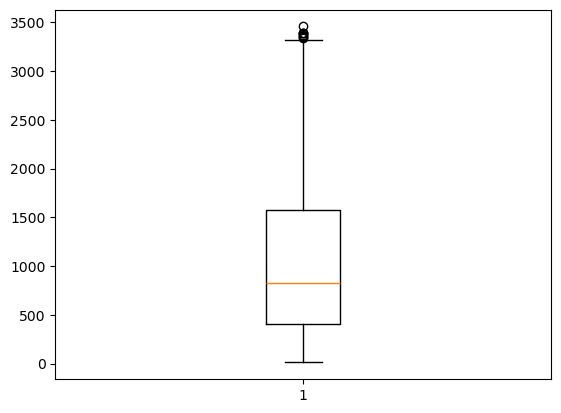

In [24]:
plt.boxplot(df["TotalPrice"])
plt.show()

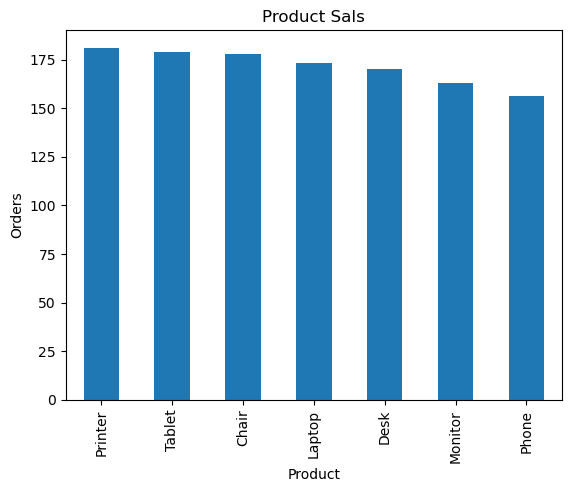

In [25]:
df["Product"].value_counts().plot(kind="bar")

plt.title("Product Sals")
plt.xlabel("Product")
plt.ylabel("Orders")

plt.show()

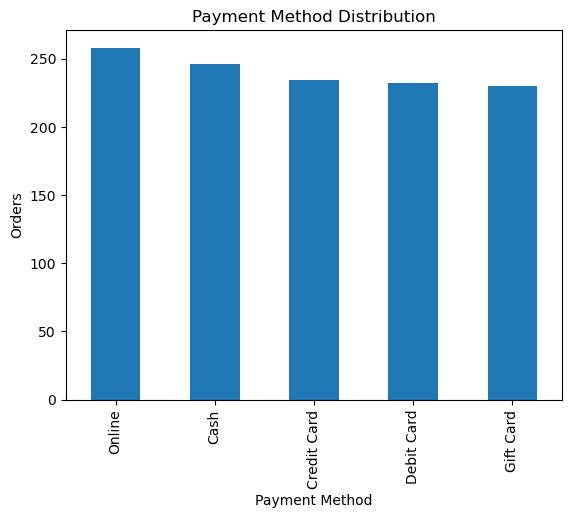

In [26]:
df["PaymentMethod"].value_counts().plot(kind="bar")

plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Orders")

plt.show()

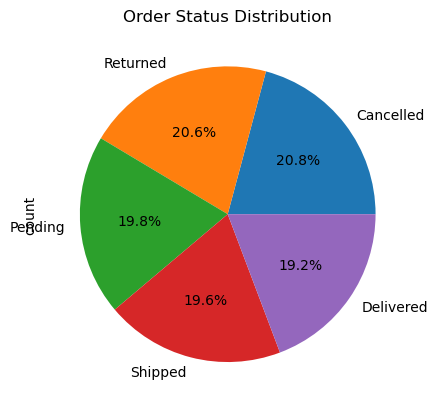

In [27]:
df["OrderStatus"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Order Status Distribution")
plt.show()

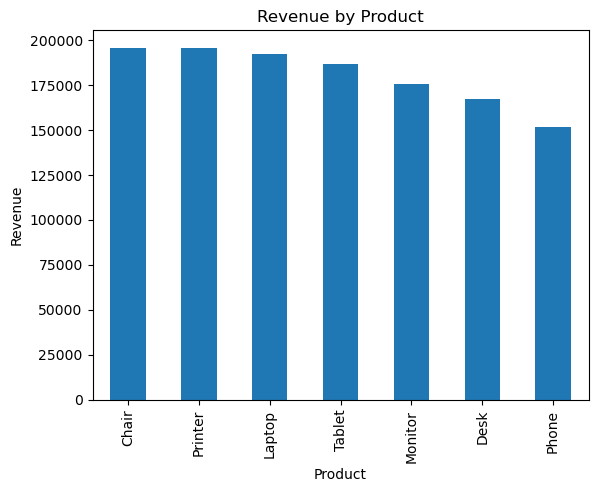

In [28]:
df.groupby("Product")["TotalPrice"].sum().sort_values(
    ascending=False
).plot(kind="bar")

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.show()

In [29]:
df.to_excel("Cleaned_Data.xlsx", index=False)

In [30]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,CalculatedPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,2504.04


In [31]:
df.shape

(1200, 15)

SQL work

In [38]:
import pandas as pd
import sqlite3

In [39]:
df = pd.read_excel("Cleaned_Data.xlsx")
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,CalculatedPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,2504.04


In [40]:
conn = sqlite3.connect("ecommerce.db")

In [41]:
df.to_sql(
    "sales",
    conn,
    if_exists="replace",
    index=False
)

1200

In [42]:
query = """
SELECT Product,
       SUM(TotalPrice) AS Revenue
FROM sales
GROUP BY Product
ORDER BY Revenue DESC;
"""

pd.read_sql_query(query, conn)

,Product,Revenue
0,Chair,195620.11
1,Printer,195612.61
2,Laptop,192126.56
3,Tablet,186568.95
4,Monitor,175651.41
5,Desk,167459.93
6,Phone,151722.39


1. Top Selling Products

In [44]:
query = """
SELECT Product,
       SUM(Quantity) AS Total_Sold
FROM sales
GROUP BY Product
ORDER BY Total_Sold DESC;
"""

result = pd.read_sql_query(query, conn)
result

,Product,Total_Sold
0,Chair,562
1,Printer,542
2,Laptop,535
3,Desk,508
4,Tablet,497
5,Monitor,480
6,Phone,411


In [45]:
pd.read_sql_query(
    "SELECT * FROM sales LIMIT 5",
    conn
)

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,CalculatedPrice
0,ORD200000,2023-01-04 00:00:00,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,2853.10
1,ORD200001,2024-08-23 00:00:00,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,302.70
2,ORD200002,2024-02-27 00:00:00,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2753.40
3,ORD200003,2023-10-15 00:00:00,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,273.19
4,ORD200004,2025-05-08 00:00:00,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,2504.04


2. Highest Revenue Products

In [46]:
query = """
SELECT Product,
SUM(TotalPrice) AS Revenue
FROM sales
GROUP BY Product
ORDER BY Revenue DESC;
"""

result = pd.read_sql_query(query, conn)
result

,Product,Revenue
0,Chair,195620.11
1,Printer,195612.61
2,Laptop,192126.56
3,Tablet,186568.95
4,Monitor,175651.41
5,Desk,167459.93
6,Phone,151722.39


3. Payment Method Analysis

In [50]:
query = """
SELECT PaymentMethod,
COUNT(*) AS Orders
FROM sales
GROUP BY PaymentMethod;
"""

result = pd.read_sql_query(query, conn)
result

,PaymentMethod,Orders
0,Cash,246
1,Credit Card,234
2,Debit Card,232
3,Gift Card,230
4,Online,258


4. Monthly Revenue

In [51]:
query = """
SELECT strftime('%Y-%m', Date) AS Month,
SUM(TotalPrice) AS Revenue
FROM sales
GROUP BY Month;
"""

result = pd.read_sql_query(query, conn)
result

,Month,Revenue
0,2023-01,56685.75
1,2023-02,40117.66
2,2023-03,48609.37
3,2023-04,27751.71
4,2023-05,63836.84
5,2023-06,49500.19
6,2023-07,42820.66
7,2023-08,54352.14
8,2023-09,29526.67
9,2023-10,52607.85


5. Top Customers

In [52]:
query = """
SELECT CustomerID,
SUM(TotalPrice) AS Spending
FROM sales
GROUP BY CustomerID
ORDER BY Spending DESC
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)
result

,CustomerID,Spending
0,C38840,5723.23
1,C57276,3456.40
2,C67260,3390.80
3,C13877,3384.90
4,C18404,3370.20
5,C16775,3353.75
6,C65986,3352.40
7,C47778,3334.00
8,C59183,3322.55
9,C25276,3313.90


ADVANCE EDA WORK

1. Top 10 Customers

<Axes: xlabel='CustomerID'>

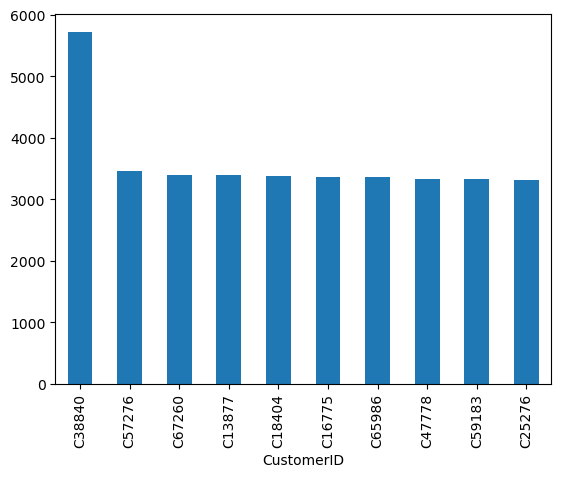

In [57]:
top_customers = df.groupby("CustomerID")["TotalPrice"].sum().sort_values(ascending=False).head(10)
top_customers.plot(kind="bar")

2. Monthly Revenue Trend

<Axes: xlabel='Month'>

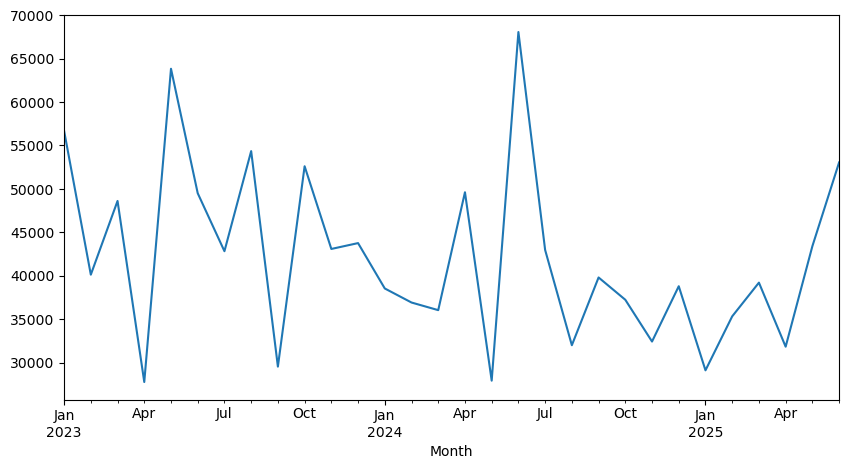

In [58]:
df["Month"] = df["Date"].dt.to_period("M")

monthly_sales = df.groupby("Month")["TotalPrice"].sum()

monthly_sales.plot(figsize=(10,5))

3. Referral Source Analysis

<Axes: xlabel='ReferralSource'>

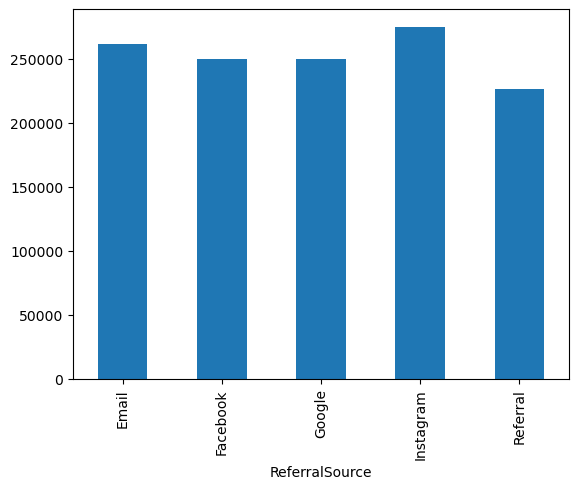

In [55]:
df.groupby("ReferralSource")["TotalPrice"].sum().plot(kind="bar")

4. Coupon Usage

<Axes: ylabel='count'>

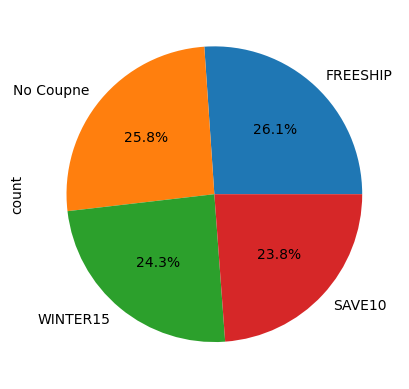

In [56]:
df["CouponCode"].value_counts().plot(kind="pie", autopct="%1.1f%%")